# Hero plus counter-pick draft model

This notebook trains `CounterInteractionDraftModel`: a smaller logistic regression over Dota drafts with independent coefficients for individual heroes and directed counter-pick pairs. It intentionally removes allied synergy parameters.

Target convention: `0` = Radiant won, `1` = Dire won. The model returns Dire-win logits, so `sigmoid(logit)` is `P(Dire win)`.


In [1]:
import copy
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module
import scripts.ml.models.counter_interaction as counter_interaction_module

importlib.reload(dataset_module)
importlib.reload(counter_interaction_module)

DatasetMaker = dataset_module.DatasetMaker
CounterInteractionDraftModel = counter_interaction_module.CounterInteractionDraftModel


## Configuration

Set each source limit to `None` to use all rows, `0` to skip it, or an integer to cap it.


In [2]:
DOTABUFF_LIMIT = None
OPENDOTA_LIMIT = None
SYNTHETIC_LIMIT = 0
PROFESSIONAL_ONLY = False

VAL_FRACTION = 0.2
BATCH_SIZE = 256
SEED = 42

LR = 3e-3
WEIGHT_DECAY = 1e-3
EPOCHS = 80
PATIENCE = 8
MIN_DELTA = 1e-4
THRESHOLD = 0.5

TOP_N = 25

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Load Training Drafts

The dataset helper reads database credentials from `.env`, normalizes hero names to numeric ids, and keeps complete 5v5 drafts with known winners.


In [3]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    drafts = dataset.fetch_normalized_training_match_drafts(
        dotabuff_limit=DOTABUFF_LIMIT,
        opendota_limit=OPENDOTA_LIMIT,
        synthetic_limit=SYNTHETIC_LIMIT,
    )

complete_drafts = [
    draft
    for draft in drafts
    if draft.winner_side is not None
    and len(draft.radiant_hero_ids) == 5
    and len(draft.dire_hero_ids) == 5
]

if PROFESSIONAL_ONLY:
    complete_drafts = [draft for draft in complete_drafts if draft.is_professional_match]

if not complete_drafts:
    raise ValueError("No complete labeled drafts found. Check .env database settings and imported match data.")

pd.DataFrame(
    {
        "matches": [len(complete_drafts)],
        "radiant_wins": [sum(draft.winner_side == 0 for draft in complete_drafts)],
        "dire_wins": [sum(draft.winner_side == 1 for draft in complete_drafts)],
        "professional_known": [sum(draft.is_professional_match is not None for draft in complete_drafts)],
        "professional_true": [sum(draft.is_professional_match is True for draft in complete_drafts)],
    }
)


,matches,radiant_wins,dire_wins,professional_known,professional_true
0,9685,5080,4605,9685,4901


In [4]:
heroes_path = PROJECT_ROOT / "dotaconstants" / "build" / "heroes.json"
heroes = json.loads(heroes_path.read_text(encoding="utf-8"))
num_heroes = max(int(hero["id"]) for hero in heroes.values()) + 1
hero_id_to_name = {
    int(hero["id"]): hero.get("localized_name") or hero["name"].removeprefix("npc_dota_hero_")
    for hero in heroes.values()
}
hero_ids = sorted(hero_id_to_name)

match_ids = torch.tensor([draft.match_id for draft in complete_drafts], dtype=torch.long)
radiant_ids = torch.tensor([draft.radiant_hero_ids for draft in complete_drafts], dtype=torch.long)
dire_ids = torch.tensor([draft.dire_hero_ids for draft in complete_drafts], dtype=torch.long)
labels = torch.tensor([draft.winner_side for draft in complete_drafts], dtype=torch.float32)

indices = np.arange(len(complete_drafts))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

val_size = max(1, int(len(indices) * VAL_FRACTION))
val_idx = torch.tensor(indices[:val_size], dtype=torch.long)
train_idx = torch.tensor(indices[val_size:], dtype=torch.long)

train_ds = TensorDataset(match_ids[train_idx], radiant_ids[train_idx], dire_ids[train_idx], labels[train_idx])
val_ds = TensorDataset(match_ids[val_idx], radiant_ids[val_idx], dire_ids[val_idx], labels[val_idx])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

pd.DataFrame(
    {
        "split": ["train", "validation"],
        "matches": [len(train_ds), len(val_ds)],
        "dire_win_rate": [labels[train_idx].mean().item(), labels[val_idx].mean().item()],
    }
)


,split,matches,dire_win_rate
0,train,7748,0.478059
1,validation,1937,0.465152


## Initialize Model

The model score is:

`bias + Dire heroes - Radiant heroes + Dire counters into Radiant - Radiant counters into Dire`.


In [5]:
train_labels = labels[train_idx]
positive_count = train_labels.sum().item()
negative_count = train_labels.numel() - positive_count
pos_weight = torch.tensor([negative_count / max(positive_count, 1.0)], dtype=torch.float32, device=device)

model = CounterInteractionDraftModel(num_heroes=num_heroes).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

pd.DataFrame(
    {
        "num_heroes": [num_heroes],
        "known_heroes": [len(hero_ids)],
        "parameters": [sum(p.numel() for p in model.parameters())],
        "pos_weight": [pos_weight.item()],
    }
)


,num_heroes,known_heroes,parameters,pos_weight
0,156,127,24493,1.091793


## Training Helpers


In [6]:
def binary_metrics_from_counts(tp, tn, fp, fn):
    total = tp + tn + fp + fn
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "accuracy": (tp + tn) / total if total else 0.0,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for _, radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        loss.backward()
        optimizer.step()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device, *, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_examples = 0
    tp = tn = fp = fn = 0

    for _, radiant_batch, dire_batch, label_batch in loader:
        radiant_batch = radiant_batch.to(device)
        dire_batch = dire_batch.to(device)
        label_batch = label_batch.to(device)

        logits = model(radiant_batch, dire_batch)
        loss = criterion(logits, label_batch)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= threshold).float()

        batch_size = label_batch.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

        tp += int(((predictions == 1) & (label_batch == 1)).sum().item())
        tn += int(((predictions == 0) & (label_batch == 0)).sum().item())
        fp += int(((predictions == 1) & (label_batch == 0)).sum().item())
        fn += int(((predictions == 0) & (label_batch == 1)).sum().item())

    metrics = binary_metrics_from_counts(tp, tn, fp, fn)
    metrics.update({"loss": total_loss / total_examples, "tp": tp, "tn": tn, "fp": fp, "fn": fn})
    return metrics


## Train


In [7]:
history = []
best_val_loss = float("inf")
best_state = None
best_epoch = 0
stale_epochs = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_metrics = evaluate(model, train_loader, criterion, device, threshold=THRESHOLD)
    val_metrics = evaluate(model, val_loader, criterion, device, threshold=THRESHOLD)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"train_{key}": value for key, value in train_metrics.items()},
        **{f"val_{key}": value for key, value in val_metrics.items()},
    }
    history.append(row)

    print(
        f"epoch={epoch:02d} "
        f"train_loss={train_loss:.4f} "
        f"train_accuracy={train_metrics['accuracy']:.3f} "
        f"train_f1={train_metrics['f1']:.3f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.3f} "
        f"val_precision={val_metrics['precision']:.3f} "
        f"val_recall={val_metrics['recall']:.3f} "
        f"val_f1={val_metrics['f1']:.3f}"
    )

    if val_metrics["loss"] < best_val_loss - MIN_DELTA:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            print(f"Early stopping at epoch={epoch}; best_epoch={best_epoch}, best_val_loss={best_val_loss:.4f}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()


epoch=01 train_loss=0.7224 train_accuracy=0.746 train_f1=0.740 val_loss=0.7206 val_accuracy=0.533 val_precision=0.498 val_recall=0.523 val_f1=0.510
epoch=02 train_loss=0.6386 train_accuracy=0.804 train_f1=0.797 val_loss=0.7258 val_accuracy=0.528 val_precision=0.493 val_recall=0.511 val_f1=0.501
epoch=03 train_loss=0.5883 train_accuracy=0.828 train_f1=0.821 val_loss=0.7317 val_accuracy=0.522 val_precision=0.487 val_recall=0.505 val_f1=0.496
epoch=04 train_loss=0.5488 train_accuracy=0.846 train_f1=0.840 val_loss=0.7412 val_accuracy=0.526 val_precision=0.490 val_recall=0.505 val_f1=0.498
epoch=05 train_loss=0.5172 train_accuracy=0.857 train_f1=0.852 val_loss=0.7525 val_accuracy=0.520 val_precision=0.484 val_recall=0.498 val_f1=0.491
epoch=06 train_loss=0.4898 train_accuracy=0.866 train_f1=0.862 val_loss=0.7641 val_accuracy=0.527 val_precision=0.491 val_recall=0.504 val_f1=0.498
epoch=07 train_loss=0.4668 train_accuracy=0.876 train_f1=0.871 val_loss=0.7771 val_accuracy=0.526 val_precision=

,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_tp,train_tn,train_fp,train_fn,val_accuracy,val_precision,val_recall,val_f1,val_loss,val_tp,val_tn,val_fp,val_fn
4,5,0.486892,0.856737,0.842940,0.860691,0.851723,3188,3450,594,516,0.519876,0.484358,0.498335,0.491247,0.752464,449,558,478,452
5,6,0.462770,0.866417,0.852576,0.871220,0.861797,3227,3486,558,477,0.526588,0.491342,0.503885,0.497534,0.764091,454,566,470,447
6,7,0.441662,0.875839,0.863083,0.879860,0.871390,3259,3527,517,445,0.526071,0.490649,0.495006,0.492818,0.777081,446,573,463,455
7,8,0.423185,0.883325,0.868034,0.891469,0.879595,3302,3542,502,402,0.524522,0.488914,0.489456,0.489185,0.790268,441,575,461,460
8,9,0.406385,0.890165,0.878081,0.894438,0.886184,3313,3584,460,391,0.524522,0.488914,0.489456,0.489185,0.801406,441,575,461,460


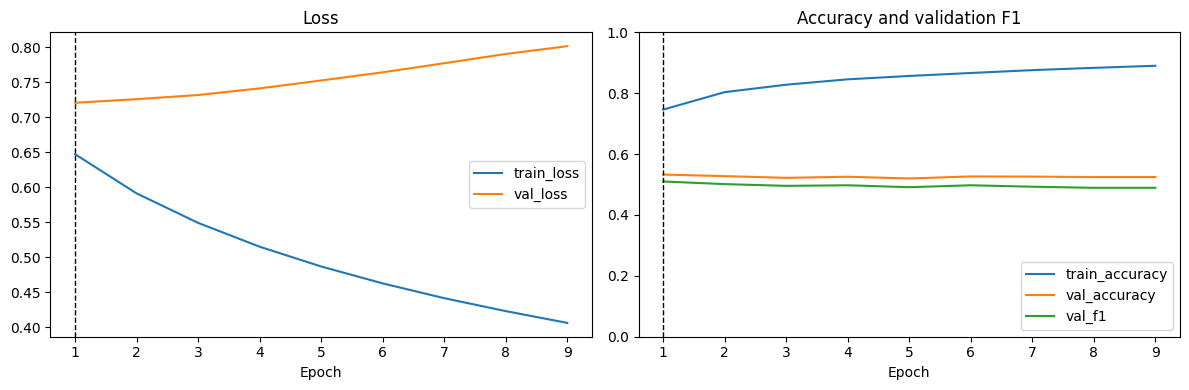

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df.plot(x="epoch", y=["train_loss", "val_loss"], ax=axes[0])
axes[0].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")

history_df.plot(x="epoch", y=["train_accuracy", "val_accuracy", "val_f1"], ax=axes[1])
axes[1].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Accuracy and validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)

plt.tight_layout()


## Validation Report


In [9]:
final_metrics = evaluate(model, val_loader, criterion, device, threshold=THRESHOLD)
val_labels = labels[val_idx]

report_df = pd.DataFrame(
    [
        {"model": "always_radiant", "accuracy": (val_labels == 0).float().mean().item(), "f1": 0.0, "loss": np.nan},
        {"model": "always_dire", "accuracy": (val_labels == 1).float().mean().item(), "f1": binary_metrics_from_counts(int((val_labels == 1).sum()), 0, int((val_labels == 0).sum()), 0)["f1"], "loss": np.nan},
        {"model": "counter_interaction", "accuracy": final_metrics["accuracy"], "f1": final_metrics["f1"], "loss": final_metrics["loss"]},
    ]
)
report_df


,model,accuracy,f1,loss
0,always_radiant,0.534848,0.000000,NaN
1,always_dire,0.465152,0.634954,NaN
2,counter_interaction,0.532783,0.510016,0.720609


In [10]:
pd.DataFrame(
    [[final_metrics["tn"], final_metrics["fp"]], [final_metrics["fn"], final_metrics["tp"]]],
    index=["actual_radiant", "actual_dire"],
    columns=["predicted_radiant", "predicted_dire"],
)


,predicted_radiant,predicted_dire
actual_radiant,561,475
actual_dire,430,471


# Learned Coefficients

The next cells are the main analysis path. Positive coefficients favor the side that owns the term. Negative coefficients hurt that side.


In [11]:
with torch.no_grad():
    hero_strength = model.hero_strength.weight.detach().cpu().squeeze(-1)
    counter_weight = model.counter.detach().cpu()


## Individual Heroes

`strength_for_side` is the direct coefficient for placing that hero on a side. A large positive value means the hero pushes the logit toward the side that drafted it.


In [12]:
hero_strength_df = pd.DataFrame(
    [
        {
            "hero_id": hero_id,
            "hero": hero_id_to_name[hero_id],
            "strength_for_side": hero_strength[hero_id].item(),
        }
        for hero_id in hero_ids
    ]
).sort_values("strength_for_side", ascending=False)

hero_strength_df.head(TOP_N)


,hero_id,hero,strength_for_side
81,83,Treant Protector,0.048965
80,82,Meepo,0.035612
87,89,Naga Siren,0.034993
40,42,Wraith King,0.034706
1,2,Axe,0.033724
34,36,Necrophos,0.033573
26,28,Slardar,0.032732
2,3,Bane,0.032443
7,8,Juggernaut,0.031628
25,27,Shadow Shaman,0.028750


In [13]:
hero_strength_df.tail(TOP_N).sort_values("strength_for_side")


,hero_id,hero,strength_for_side
46,48,Luna,-0.047518
16,17,Storm Spirit,-0.044745
12,13,Puck,-0.043459
107,109,Terrorblade,-0.039534
37,39,Queen of Pain,-0.035881
36,38,Beastmaster,-0.033184
0,1,Anti-Mage,-0.030748
62,64,Jakiro,-0.030089
23,25,Lina,-0.029296
92,94,Medusa,-0.025999


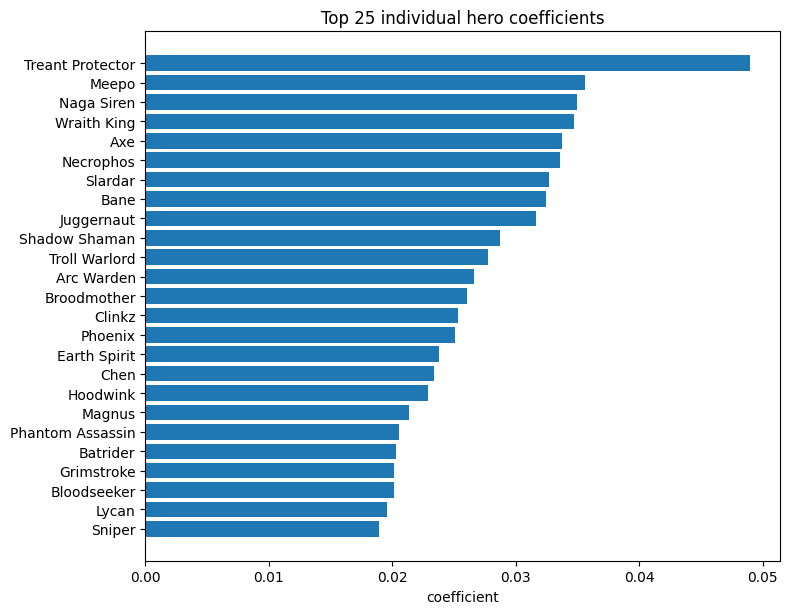

In [14]:
fig, ax = plt.subplots(figsize=(8, max(4, TOP_N * 0.25)))
plot_df = hero_strength_df.head(TOP_N).sort_values("strength_for_side")
ax.barh(plot_df["hero"], plot_df["strength_for_side"])
ax.set_title(f"Top {TOP_N} individual hero coefficients")
ax.set_xlabel("coefficient")
plt.tight_layout()


## Directed Counter-Picks

The interpretable matchup score is `counter[attacker, victim] - counter[victim, attacker]`. Positive values mean the attacker is good into the victim for the attacker's side.


In [15]:
counter_rows = []
for attacker_id in hero_ids:
    for victim_id in hero_ids:
        if attacker_id == victim_id:
            continue
        counter_score = counter_weight[attacker_id, victim_id].item()
        reverse_score = counter_weight[victim_id, attacker_id].item()
        matchup_score = counter_score - reverse_score
        counter_rows.append(
            {
                "attacker": hero_id_to_name[attacker_id],
                "victim": hero_id_to_name[victim_id],
                "counter_score": counter_score,
                "reverse_counter_score": reverse_score,
                "matchup_score": matchup_score,
            }
        )

counter_df = pd.DataFrame(counter_rows).sort_values("matchup_score", ascending=False)
counter_df.head(TOP_N)


,attacker,victim,counter_score,reverse_counter_score,matchup_score
13402,Underlord,Luna,0.062742,-0.062742,0.125484
14653,Hoodwink,Queen of Pain,0.060168,-0.060168,0.120336
11860,Centaur Warrunner,Storm Spirit,0.058240,-0.058240,0.116479
12612,Abaddon,Puck,0.056941,-0.056941,0.113883
10233,Treant Protector,Tidehunter,0.055365,-0.055365,0.110730
11170,Keeper of the Light,Ogre Magi,0.054760,-0.054760,0.109519
7405,Night Stalker,Tusk,0.054386,-0.054386,0.108772
3589,Witch Doctor,Jakiro,0.053893,-0.053893,0.107785
11184,Keeper of the Light,Bristleback,0.053870,-0.053870,0.107739
15259,Dawnbreaker,Pudge,0.051767,-0.051767,0.103534


In [16]:
counter_df.tail(TOP_N).sort_values("matchup_score")


,attacker,victim,counter_score,reverse_counter_score,matchup_score
5901,Luna,Underlord,-0.062742,0.062742,-0.125484
4777,Queen of Pain,Hoodwink,-0.060168,0.060168,-0.120336
2109,Storm Spirit,Centaur Warrunner,-0.058240,0.058240,-0.116479
1611,Puck,Abaddon,-0.056941,0.056941,-0.113883
3482,Tidehunter,Treant Protector,-0.055365,0.055365,-0.110730
10419,Ogre Magi,Keeper of the Light,-0.054760,0.054760,-0.109519
12406,Tusk,Night Stalker,-0.054386,0.054386,-0.108772
7840,Jakiro,Witch Doctor,-0.053893,0.053893,-0.107785
12310,Bristleback,Keeper of the Light,-0.053870,0.053870,-0.107739
1758,Pudge,Dawnbreaker,-0.051767,0.051767,-0.103534


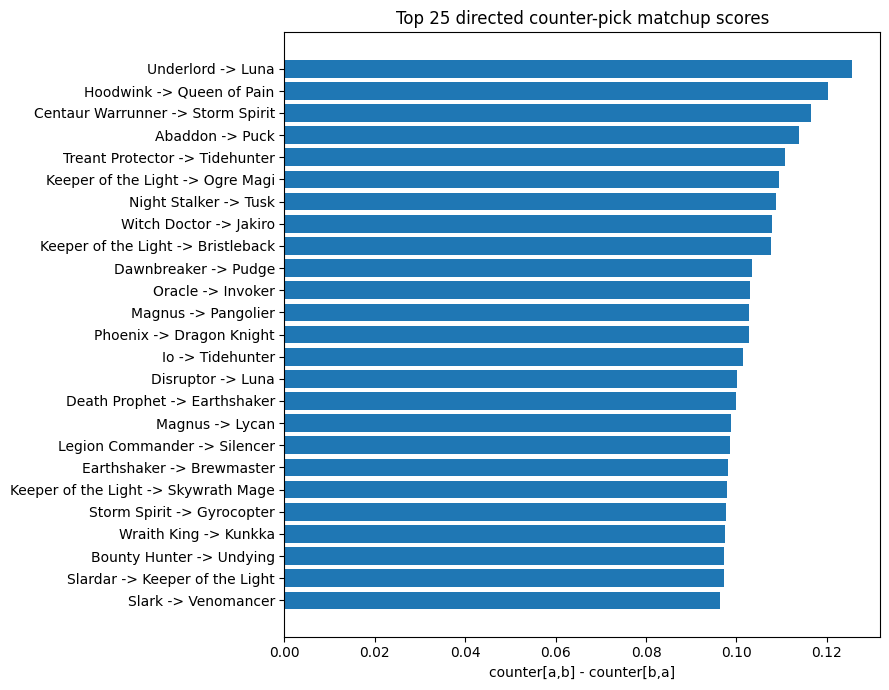

In [17]:
fig, ax = plt.subplots(figsize=(9, max(4, TOP_N * 0.28)))
plot_df = counter_df.head(TOP_N).copy()
plot_df["matchup"] = plot_df["attacker"] + " -> " + plot_df["victim"]
plot_df = plot_df.sort_values("matchup_score")
ax.barh(plot_df["matchup"], plot_df["matchup_score"])
ax.set_title(f"Top {TOP_N} directed counter-pick matchup scores")
ax.set_xlabel("counter[a,b] - counter[b,a]")
plt.tight_layout()


## Hero Drilldown

Use this helper to inspect one hero: its individual coefficient, heroes it counters, and heroes that counter it.


In [18]:
def hero_report(hero_name, *, top_n=15):
    with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
        hero_id = dataset.hero_name_to_id(hero_name)

    hero = hero_id_to_name[hero_id]
    individual = hero_strength[hero_id].item()

    counters_rows = []
    countered_by_rows = []
    for other_id in hero_ids:
        if other_id == hero_id:
            continue
        selected_into_other = counter_weight[hero_id, other_id].item()
        other_into_selected = counter_weight[other_id, hero_id].item()
        matchup_score = selected_into_other - other_into_selected
        counters_rows.append(
            {
                "victim": hero_id_to_name[other_id],
                "selected_into_victim": selected_into_other,
                "victim_into_selected": other_into_selected,
                "matchup_score": matchup_score,
            }
        )
        countered_by_rows.append(
            {
                "attacker": hero_id_to_name[other_id],
                "attacker_into_selected": other_into_selected,
                "selected_into_attacker": selected_into_other,
                "matchup_score": -matchup_score,
            }
        )

    return {
        "hero": hero,
        "individual_strength": individual,
        "best_victims": pd.DataFrame(counters_rows).sort_values("matchup_score", ascending=False).head(top_n),
        "worst_threats": pd.DataFrame(countered_by_rows).sort_values("matchup_score", ascending=False).head(top_n),
    }

report = hero_report("phantom lancer", top_n=TOP_N)
report["hero"], report["individual_strength"]


('Phantom Lancer', -0.021925782784819603)

In [19]:
report["best_victims"]


,victim,selected_into_victim,victim_into_selected,matchup_score
14,Sand King,0.034942,-0.034942,0.069884
124,Kez,0.031774,-0.031774,0.063548
10,Shadow Fiend,0.031369,-0.031369,0.062737
37,Venomancer,0.027706,-0.027706,0.055413
36,Queen of Pain,0.027181,-0.027181,0.054362
114,Grimstroke,0.027173,-0.027173,0.054346
25,Slardar,0.026148,-0.026148,0.052295
76,Shadow Demon,0.025027,-0.025027,0.050055
73,Outworld Devourer,0.024128,-0.024128,0.048256
125,Largo,0.024054,-0.024054,0.048109


In [20]:
report["worst_threats"]


,attacker,attacker_into_selected,selected_into_attacker,matchup_score
49,Leshrac,0.047409,-0.047409,0.094818
96,Bristleback,0.041737,-0.041737,0.083474
1,Axe,0.039143,-0.039143,0.078286
33,Necrophos,0.033917,-0.033917,0.067835
59,Bounty Hunter,0.032682,-0.032682,0.065365
2,Bane,0.032341,-0.032341,0.064683
32,Sniper,0.032030,-0.032030,0.064059
78,Chaos Knight,0.031973,-0.031973,0.063947
80,Treant Protector,0.031692,-0.031692,0.063384
38,Faceless Void,0.030050,-0.030050,0.060100


## Draft Explanation

The helper below decomposes one custom draft into hero and counter-pick contributions.


In [21]:
def explain_draft(radiant_hero_names, dire_hero_names):
    if len(radiant_hero_names) != 5 or len(dire_hero_names) != 5:
        raise ValueError("Both teams must contain exactly five heroes.")

    with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
        radiant = [dataset.hero_name_to_id(hero) for hero in radiant_hero_names]
        dire = [dataset.hero_name_to_id(hero) for hero in dire_hero_names]

    radiant_tensor = torch.tensor([radiant], dtype=torch.long, device=device)
    dire_tensor = torch.tensor([dire], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        logit = model(radiant_tensor, dire_tensor).cpu().item()
    dire_probability = 1 / (1 + np.exp(-logit))

    rows = []
    for side_name, sign, team in [("radiant", -1, radiant), ("dire", 1, dire)]:
        for hero_id in team:
            rows.append({"group": "hero", "side": side_name, "term": hero_id_to_name[hero_id], "contribution_to_dire_logit": sign * hero_strength[hero_id].item()})

    for attacker_side, sign, attackers, victims in [
        ("dire", 1, dire, radiant),
        ("radiant", -1, radiant, dire),
    ]:
        for attacker in attackers:
            for victim in victims:
                rows.append({"group": "counter", "side": attacker_side, "term": f"{hero_id_to_name[attacker]} -> {hero_id_to_name[victim]}", "contribution_to_dire_logit": sign * counter_weight[attacker, victim].item()})

    contribution_df = pd.DataFrame(rows).sort_values("contribution_to_dire_logit", ascending=False)
    return {
        "radiant_win_probability": 1 - dire_probability,
        "dire_win_probability": dire_probability,
        "predicted_winner": "dire" if dire_probability >= THRESHOLD else "radiant",
        "logit": logit,
        "contributions": contribution_df,
    }

example = explain_draft(
    radiant_hero_names=["anti mage", "crystal maiden", "axe", "puck", "lich"],
    dire_hero_names=["juggernaut", "shadow fiend", "lion", "centaur warrunner", "witch doctor"],
)
{key: value for key, value in example.items() if key != "contributions"}


{'radiant_win_probability': 0.4190779593969871,
 'dire_win_probability': 0.5809220406030129,
 'predicted_winner': 'dire',
 'logit': 0.3265596032142639}

In [22]:
example["contributions"].head(20)


,group,side,term,contribution_to_dire_logit
3,hero,radiant,Puck,0.043459
40,counter,radiant,Crystal Maiden -> Juggernaut,0.035927
11,counter,dire,Juggernaut -> Crystal Maiden,0.035927
5,hero,dire,Juggernaut,0.031628
0,hero,radiant,Anti-Mage,0.030748
53,counter,radiant,Puck -> Centaur Warrunner,0.030580
28,counter,dire,Centaur Warrunner -> Puck,0.030580
49,counter,radiant,Axe -> Witch Doctor,0.023926
32,counter,dire,Witch Doctor -> Axe,0.023926
57,counter,radiant,Lich -> Lion,0.020302


In [23]:
example["contributions"].tail(20).sort_values("contribution_to_dire_logit")


,group,side,term,contribution_to_dire_logit
2,hero,radiant,Axe,-0.033724
6,hero,dire,Shadow Fiend,-0.022142
22,counter,dire,Lion -> Axe,-0.020281
47,counter,radiant,Axe -> Lion,-0.020281
33,counter,dire,Witch Doctor -> Puck,-0.016454
54,counter,radiant,Puck -> Witch Doctor,-0.016454
58,counter,radiant,Lich -> Centaur Warrunner,-0.013479
29,counter,dire,Centaur Warrunner -> Lich,-0.013479
1,hero,radiant,Crystal Maiden,-0.008241
37,counter,radiant,Anti-Mage -> Lion,-0.007619
